In [1]:
from google.colab import files

uploaded = files.upload()

Saving ride-hail-trips.csv to ride-hail-trips.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("ride-hail-trips.csv")

df["pickup_at"] = pd.to_datetime(df["pickup_at"])

df["hour"] = df["pickup_at"].dt.hour
df["day"] = df["pickup_at"].dt.day_name()
df["date"] = df["pickup_at"].dt.date

df = df.drop_duplicates()

print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

display(df.head())

Shape: (8000, 13)

Missing Values:
trip_id             0
pickup_at           0
borough             0
distance_km         0
duration_min        0
fare_usd            0
tip_usd             0
surge_multiplier    0
payment_type        0
passengers          0
hour                0
day                 0
date                0
dtype: int64

Duplicates: 0


,trip_id,pickup_at,borough,distance_km,duration_min,fare_usd,tip_usd,surge_multiplier,payment_type,passengers,hour,day,date
0,T103975,2023-01-01 02:27:59,Downtown,1.88,10.2,8.93,2.22,1.0,card,3,2,Sunday,2023-01-01
1,T100500,2023-01-01 08:05:36,Downtown,1.93,11.6,18.87,3.78,2.0,card,1,8,Sunday,2023-01-01
2,T102112,2023-01-01 08:13:48,Midtown,4.44,21.6,16.10,3.51,1.0,card,2,8,Sunday,2023-01-01
3,T101754,2023-01-01 08:48:01,Uptown,4.18,23.7,21.30,2.17,1.3,card,6,8,Sunday,2023-01-01
4,T107670,2023-01-01 09:18:22,Harbour,2.25,12.3,10.11,0.96,1.0,wallet,3,9,Sunday,2023-01-01


In [3]:
print("Total Trips:", len(df))

print("\nTrips by Borough:")
display(df["borough"].value_counts())

print("\nTrips by Hour:")
hour_demand = df.groupby("hour").size().reset_index(name="Trips")
display(hour_demand)

print("\nTrips by Day:")
day_demand = df.groupby("day").size().reset_index(name="Trips")
display(day_demand)

Total Trips: 8000

Trips by Borough:


,count
borough,
Downtown,2399
Midtown,2034
Uptown,1453
Harbour,1149
Airport,965



Trips by Hour:


,hour,Trips
0,0,168
1,1,136
2,2,100
3,6,187
4,7,457
5,8,772
6,9,622
7,11,337
8,12,422
9,13,379



Trips by Day:


,day,Trips
0,Friday,1062
1,Monday,1188
2,Saturday,1161
3,Sunday,1127
4,Thursday,1195
5,Tuesday,1118
6,Wednesday,1149


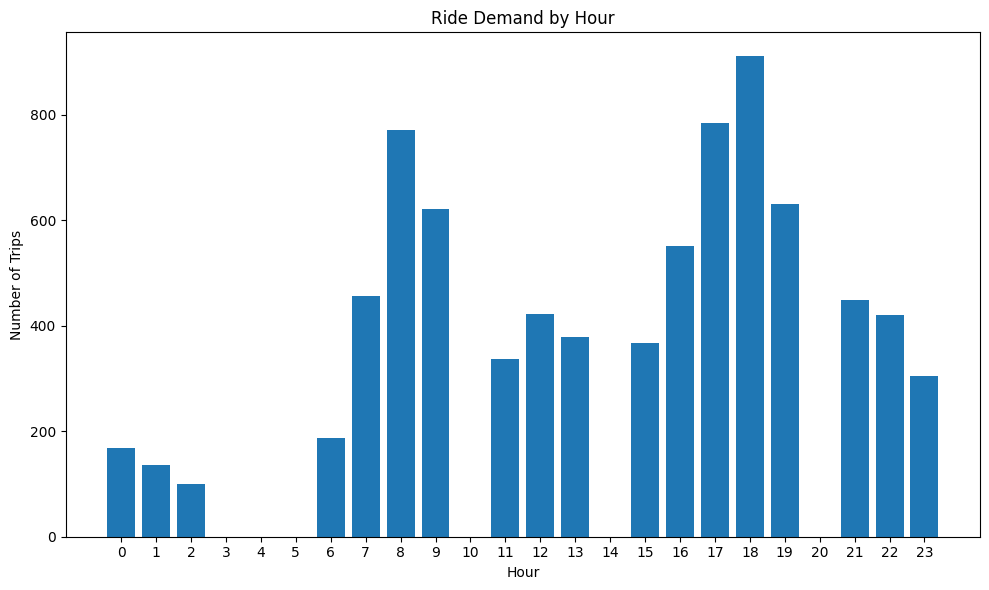

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(hour_demand["hour"], hour_demand["Trips"])

plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.title("Ride Demand by Hour")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [5]:
borough_demand = df["borough"].value_counts().reset_index()
borough_demand.columns = ["Borough", "Trips"]

display(borough_demand)

,Borough,Trips
0,Downtown,2399
1,Midtown,2034
2,Uptown,1453
3,Harbour,1149
4,Airport,965


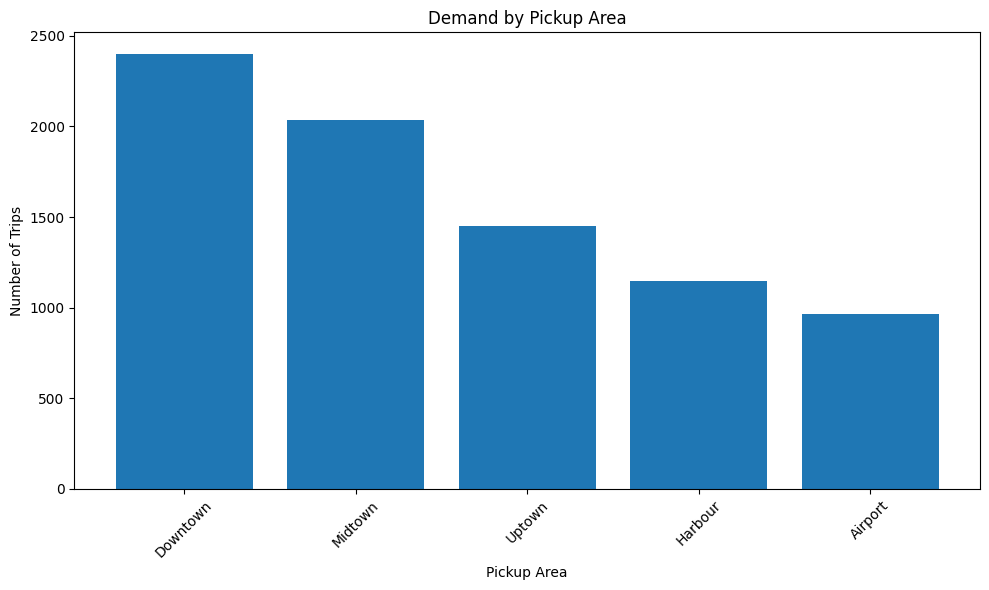

In [6]:
plt.figure(figsize=(10,6))

plt.bar(
    borough_demand["Borough"],
    borough_demand["Trips"]
)

plt.xlabel("Pickup Area")
plt.ylabel("Number of Trips")
plt.title("Demand by Pickup Area")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
surge_summary = df.groupby("surge_multiplier").agg(
    Trips=("trip_id", "count"),
    Average_Fare=("fare_usd", "mean"),
    Average_Duration=("duration_min", "mean")
).reset_index()

display(surge_summary)

,surge_multiplier,Trips,Average_Fare,Average_Duration
0,1.0,5876,15.859535,18.952349
1,1.2,41,21.737073,25.175610
2,1.3,81,22.619259,23.908642
3,1.4,98,24.737041,23.722449
4,1.5,105,24.935143,22.308571
5,1.6,98,29.358776,25.431633
6,1.7,88,29.000682,22.906818
7,1.8,110,30.682455,23.422727
8,1.9,79,36.283797,26.455696
9,2.0,94,32.820000,22.406383


In [8]:
surge_hour = df.groupby("hour").agg(
    Total_Trips=("trip_id", "count"),
    Surge_Trips=("surge_multiplier", lambda x: (x > 1).sum())
).reset_index()

surge_hour["Surge_Rate"] = (
    surge_hour["Surge_Trips"] /
    surge_hour["Total_Trips"] * 100
)

display(surge_hour)

,hour,Total_Trips,Surge_Trips,Surge_Rate
0,0,168,0,0.000000
1,1,136,0,0.000000
2,2,100,0,0.000000
3,6,187,0,0.000000
4,7,457,205,44.857768
5,8,772,352,45.595855
6,9,622,267,42.926045
7,11,337,0,0.000000
8,12,422,0,0.000000
9,13,379,0,0.000000


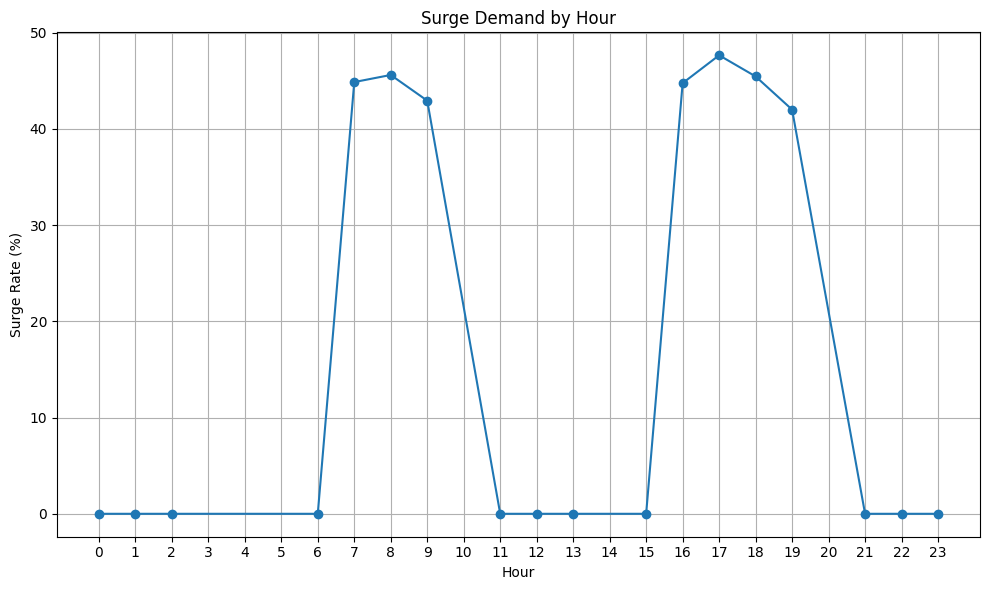

In [9]:
plt.figure(figsize=(10,6))

plt.plot(
    surge_hour["hour"],
    surge_hour["Surge_Rate"],
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Surge Rate (%)")
plt.title("Surge Demand by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
long_trips = df.sort_values(
    "duration_min",
    ascending=False
)

display(
    long_trips[
        [
            "trip_id",
            "borough",
            "distance_km",
            "duration_min",
            "fare_usd",
            "surge_multiplier"
        ]
    ].head(10)
)

,trip_id,borough,distance_km,duration_min,fare_usd,surge_multiplier
47,T106548,Airport,43.09,130.0,104.59,1.0
1288,T102832,Airport,24.13,130.0,147.56,1.9
3686,T105336,Airport,35.50,130.0,253.29,2.7
445,T106453,Uptown,37.17,130.0,96.18,1.0
1380,T105972,Airport,33.53,130.0,91.01,1.0
6468,T104157,Airport,39.78,130.0,149.83,1.5
3653,T105888,Airport,26.91,130.0,97.93,1.2
3010,T103589,Airport,33.15,130.0,90.47,1.0
7429,T102033,Airport,26.72,130.0,227.76,2.8
3056,T104129,Airport,30.75,130.0,269.90,3.1


In [11]:
borough_duration = df.groupby("borough").agg(
    Trips=("trip_id", "count"),
    Average_Duration=("duration_min", "mean"),
    Average_Distance=("distance_km", "mean"),
    Average_Fare=("fare_usd", "mean")
).reset_index()

display(
    borough_duration.sort_values(
        "Average_Duration",
        ascending=False
    )
)

,borough,Trips,Average_Duration,Average_Distance,Average_Fare
0,Airport,965,53.766736,14.765492,55.916218
4,Uptown,1453,15.676325,3.507460,17.508513
3,Midtown,2034,15.615536,3.469095,17.393668
1,Downtown,2399,15.413297,3.472609,17.922835
2,Harbour,1149,15.199130,3.425587,17.005065


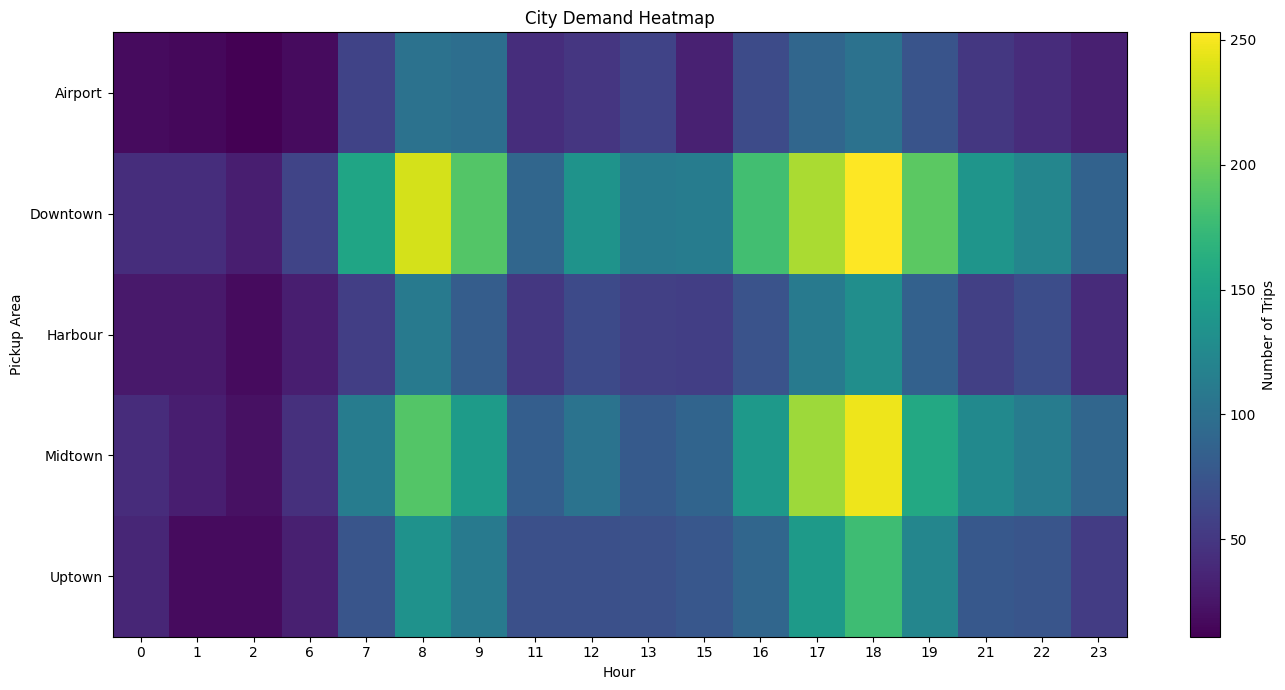

In [12]:
heatmap_data = df.pivot_table(
    index="borough",
    columns="hour",
    values="trip_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(14,7))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Hour")
plt.ylabel("Pickup Area")
plt.title("City Demand Heatmap")

plt.colorbar(label="Number of Trips")

plt.tight_layout()
plt.show()

In [13]:
df["surge_target"] = (
    df["surge_multiplier"] > 1
).astype(int)

print(df["surge_target"].value_counts())

surge_target
0    5876
1    2124
Name: count, dtype: int64


In [14]:
features = [
    "borough",
    "distance_km",
    "duration_min",
    "fare_usd",
    "tip_usd",
    "passengers",
    "hour"
]

X = df[features]
y = df["surge_target"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (6400, 7)
Testing: (1600, 7)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "borough"
]

numerical_features = [
    "distance_km",
    "duration_min",
    "fare_usd",
    "tip_usd",
    "passengers",
    "hour"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=150,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9881
Precision: 1.0
Recall: 0.9553
F1 Score: 0.9771

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1175
           1       1.00      0.96      0.98       425

    accuracy                           0.99      1600
   macro avg       0.99      0.98      0.98      1600
weighted avg       0.99      0.99      0.99      1600


Confusion Matrix:
[[1175    0]
 [  19  406]]


In [19]:
rf = model.named_steps["classifier"]

encoder = model.named_steps["preprocessor"]

feature_names = encoder.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance.head(10))

,Feature,Importance
7,num__fare_usd,0.515473
5,num__distance_km,0.165781
8,num__tip_usd,0.115407
10,num__hour,0.090854
6,num__duration_min,0.088023
0,cat__borough_Airport,0.010086
9,num__passengers,0.006464
1,cat__borough_Downtown,0.002509
4,cat__borough_Uptown,0.002099
3,cat__borough_Midtown,0.001783


In [20]:
import joblib

joblib.dump(
    model,
    "ride_hailing_surge_model.pkl"
)

print("Model saved successfully")

Model saved successfully
